In [1]:
import numpy as np
import matplotlib.pyplot as plt
import re
import os

In [2]:
try:
    BASE_DIR = os.path.dirname(__file__)
except NameError:
    BASE_DIR = os.getcwd()
DATA_DIR = "data/"

_PATTERN_1D = re.compile(
    r"^fsol_final_yuk_(?P<vertex>[^_]+(?:_[^_]+)*)__"
    r"E_(?P<E>[0-9.]+)_z_(?P<z>[0-9.]+)_q_(?P<q>[0-9.]+)_mu_(?P<mu>[0-9.]+)\.dat$"
)
_PATTERN_3D = re.compile(
    r"^fsol3D_final_yuk_(?P<vertex>[^_]+(?:_[^_]+)*)__"
    r"E_(?P<E>[0-9.]+)_z_(?P<z>[0-9.]+)_q_(?P<q>[0-9.]+)_mu_(?P<mu>[0-9.]+)"
    r"(?:_L_(?P<L>[0-9.]+))?\.dat$"
)


def _parse_yuk_files(data_dir=DATA_DIR):
    """Return two dicts:
      files_1d: (vertex, E, z, q, mu)        -> path
      files_3d: (vertex, E, z, q, mu, L)     -> path   (L is None if absent)
    """
    files_1d = {}
    files_3d = {}
    for fname in os.listdir(data_dir):
        m = _PATTERN_1D.match(fname)
        if m:
            key = (m["vertex"], float(m["E"]), float(m["z"]), float(m["q"]), float(m["mu"]))
            files_1d[key] = os.path.join(data_dir, fname)
            continue
        m = _PATTERN_3D.match(fname)
        if m:
            L_val = float(m["L"]) if m["L"] else None
            key = (m["vertex"], float(m["E"]), float(m["z"]), float(m["q"]), float(m["mu"]), L_val)
            files_3d[key] = os.path.join(data_dir, fname)
    return files_1d, files_3d


def find_pairs(E, qtilde, L, Mu, vertex=None, data_dir=DATA_DIR):
    """
    Find all (fsol, fsol3D) pairs for Yukawa with given E, qtilde, and L.
    z is auto-detected from whatever files exist.

    Returns a list of dicts, each with:
      'z', 'mu', 'L', 'vertex', 'path_1d', 'path_3d'
    Sorted by (z, mu).
    """
    files_1d, files_3d = _parse_yuk_files(data_dir)
    pairs = []
    for (v, e, z, q, mu), path_1d in files_1d.items():
        if abs(e - E) > 1e-9 or abs(q - qtilde) > 1e-9 or abs(Mu - mu) > 1e-9:
            continue
        if vertex is not None and v != vertex:
            continue
        key_3d = (v, e, z, q, mu, L)
        if key_3d in files_3d:
            path_3d = files_3d[key_3d]
            pairs.append(dict(vertex=v, E=e, z=z, mu=mu, L=L,
                               path_1d=path_1d, path_3d=path_3d))
    pairs.sort(key=lambda p: (p["z"], p["mu"]))
    return pairs


def load_pair(pair, Np=512):
    """
    Load a single (fsol, fsol3D) pair.

    Returns:
      f_out : complex array of shape (Np,)   — 1D kernel wavefunction
      f_in  : real array from fsol3D
      P     : transverse momentum grid  [0, Lp]
      K     : grid for f_in  (same length as f_in)
    """
    E, z = pair["E"], pair["z"]
    omega = E * z * (1.0 - z)
    Lp = omega

    raw = np.loadtxt(pair["path_1d"])
    f_out = raw[:, 0] + 1j * raw[:, 1]
    raw_in = np.loadtxt(pair["path_3d"])
    
    f_in = raw_in

    P = np.linspace(0, Lp, Np, dtype=np.float64)
    K = np.linspace(0, 0.5 * Lp, len(f_in), dtype=np.float64)

    f_out = np.real(f_out) 
    
    return np.real(f_out), np.real(f_in), P, K

Pair 0: z=0.01, mu=0.3
Pair 1: z=0.02, mu=0.3
Pair 2: z=0.03, mu=0.3
Pair 3: z=0.04, mu=0.3
Pair 4: z=0.05, mu=0.3
Pair 5: z=0.07, mu=0.3
Pair 6: z=0.1, mu=0.3
Pair 7: z=0.15, mu=0.3
Pair 8: z=0.2, mu=0.3
Pair 9: z=0.25, mu=0.3
Pair 10: z=0.3, mu=0.3
Pair 11: z=0.4, mu=0.3
Pair 12: z=0.5, mu=0.3


Text(0, 0.5, '$f_\\text{in} + f_\\text{out}$ (scaled)')

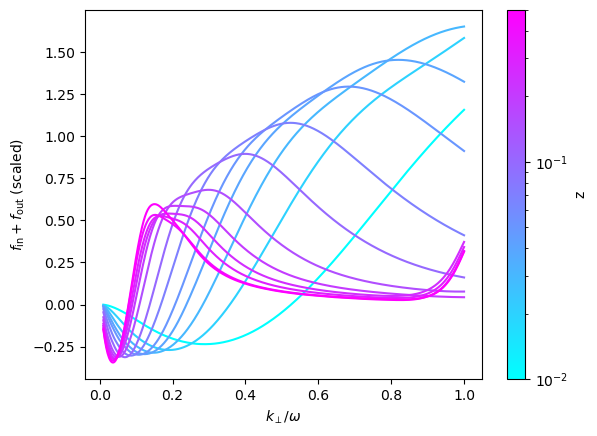

In [3]:
from scipy.interpolate import CubicSpline   
from matplotlib.colors import LogNorm

relevant_pairs = find_pairs(200, 1.5, 4, 0.3, vertex = "q_qg")
coeffs = [7, 5, 5, 5, 4, 3.5, 3, 2.5, 2.5, 2., 2., 2., 2., 2., 2.]
cmap = plt.get_cmap('cool')
norm = LogNorm(vmin=0.01, vmax=0.5)
ZS = [pair['z'] for pair in relevant_pairs]
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

Nn = 512
Fmed = np.zeros([len(ZS), Nn])

for i in range(len(relevant_pairs)):
    print(f"Pair {i}: z={relevant_pairs[i]['z']}, mu={relevant_pairs[i]['mu']}")
    fout, fin, P, K = load_pair(relevant_pairs[i])
    z = relevant_pairs[i]['z']
    omega = P[-1]

    P_eff = coeffs[i] * P
    #plt.plot(P_eff / omega, fout * P_eff / omega, label=f"z={relevant_pairs[i]['z']}, mu={relevant_pairs[i]['mu']}")

    K_eff = coeffs[i] * K

    #plt.plot(K_eff / omega, 0.5 * K_eff**2 / omega**2 * fin, label=f"z={relevant_pairs[i]['z']}, mu={relevant_pairs[i]['mu']}")

    f_in_interp = CubicSpline(K_eff / omega, 0.5 * K_eff**2 / omega**2 * fin, bc_type='natural')
    f_out_interp = CubicSpline(P_eff / omega, fout * P_eff / omega, bc_type='natural')

    k_comm = np.linspace(0.01, 1.0, Nn)

    f_in_interp_comm = f_in_interp(k_comm)
    f_out_interp_comm = f_out_interp(k_comm)

    plt.plot(k_comm, f_in_interp_comm + f_out_interp_comm, color=cmap(norm(z)))

    Fmed[i, :] = f_in_interp_comm + f_out_interp_comm

cbar = plt.colorbar(sm, ax=plt.gca())
cbar.ax.yaxis.set_label_position('right')
cbar.ax.set_ylabel('z')
plt.xlabel(r"$k_\perp / \omega$")
plt.ylabel(r"$f_\text{in} + f_\text{out}$ (scaled)")
#plt.title("Comparison of f_in and f_out for different z")
#plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

In [4]:
from scipy.interpolate import RectBivariateSpline
fmed_interp = RectBivariateSpline(ZS, k_comm, Fmed)
Np = 256

Zn = np.logspace(-4.6, np.log(np.max(ZS)), base = np.e, num = Np)
Thetan = np.logspace(-3.5, 1, base=np.e, num=Np) 

KT = 200 * Zn * (1 - Zn) * Thetan

ktmesh, Zmesh = np.meshgrid(KT, Zn)

In [5]:
Fmed_kt_z = np.zeros_like(ktmesh)

for ikt, kt in enumerate(KT):
    for iz, z in enumerate(Zn):

        theta = kt / (200 * z * (1 - z))
        Fmed_interp_val = fmed_interp(z, theta)
        if theta < 1:
            Fmed_kt_z[ikt, iz] = Fmed_interp_val[0][0]
        else:
            Fmed_kt_z[ikt, iz] = np.nan


In [6]:
def P_gq(z):
    
    return (1 + (1 - z)**2) / z

def spec(z):
    alphas = 0.3
    CF = 4/3
    return 2*alphas*CF / np.pi * z * P_gq(z)

$$\theta = k_t/(Ez(1-z)) $$ 

In [7]:
qhat = 1.5 * 1.5/5**2
L = 4 * 5

theta_c = (qhat * L**3)**(-1/2)

/tmp/ipykernel_693563/1938638610.py:2: RuntimeWarning: invalid value encountered in sqrt
  plt.plot(np.log(KT), np.log(theta_c)-np.log(0.5 - 0.5 * np.sqrt(1 - 4 * KT/(200))), color='green', linewidth = 2, label=r"$\theta$ = $\theta_c$")
/tmp/ipykernel_693563/1938638610.py:3: RuntimeWarning: invalid value encountered in sqrt
  plt.plot(np.log(KT), np.log(1.0)-np.log(0.5 - 0.5 * np.sqrt(1 - 4 * KT/(200))), color='gray', linewidth = 3, label=r"$\theta$ = 1.0")
/tmp/ipykernel_693563/1938638610.py:4: RuntimeWarning: invalid value encountered in sqrt
  plt.plot(np.log(KT), np.log(0.4)-np.log(0.5 - 0.5 * np.sqrt(1 - 4 * KT/(200))), color='blue', linewidth = 3, label=r"$\theta$ = 0.4")


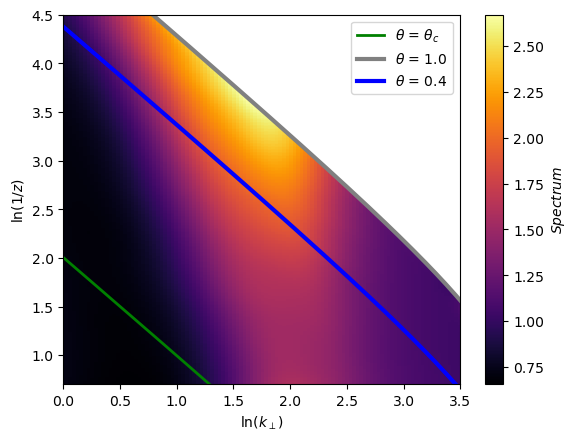

In [16]:
plt.pcolormesh(np.log(KT), -np.log(Zn), (1 + Fmed_kt_z.T), rasterized=True, cmap = 'inferno')
plt.plot(np.log(KT), np.log(theta_c)-np.log(0.5 - 0.5 * np.sqrt(1 - 4 * KT/(200))), color='green', linewidth = 2, label=r"$\theta$ = $\theta_c$")
plt.plot(np.log(KT), np.log(1.0)-np.log(0.5 - 0.5 * np.sqrt(1 - 4 * KT/(200))), color='gray', linewidth = 3, label=r"$\theta$ = 1.0")
plt.plot(np.log(KT), np.log(0.4)-np.log(0.5 - 0.5 * np.sqrt(1 - 4 * KT/(200))), color='blue', linewidth = 3, label=r"$\theta$ = 0.4")
#plt.plot(np.log(KT), -np.log(0.5 - 0.5 * np.sqrt(1 - 4 * KT**4/(200*qhat))), color='gray', linewidth = 3, label=r"$\theta$ = \theta_f")
plt.plot(8)
plt.ylim(0.7, 4.5)
plt.colorbar(label=r"$Spectrum$")
plt.xlim(0, 3.5)
plt.xlabel(r"$\ln(k_\perp)$")
plt.ylabel(r"$\ln(1/z)$")
plt.legend()
plt.show()

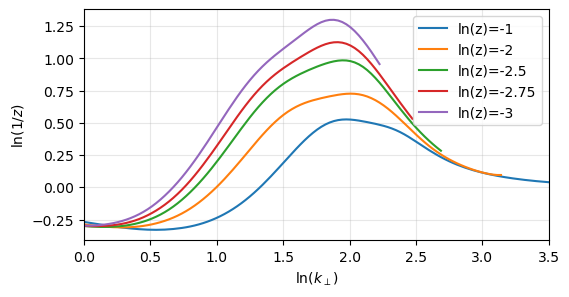

In [13]:
lnzvals = [-1, -2, -2.5, -2.75, -3]
plt.figure(figsize=(6, 3))
for lnz in lnzvals:
    z = np.exp(lnz)
    idx = np.argmin(np.abs(Zn - z))
    plt.plot(np.log(KT), (Fmed_kt_z[:, idx]), label=f"ln(z)={lnz}")
    np.save(f"fmed_kt_z_ln{lnz}.npy", Fmed_kt_z[:, idx],)
plt.xlim(0, 3.5)
plt.xlabel(r"$\ln(k_\perp)$")
plt.ylabel(r"$\ln(1/z)$")
plt.grid(alpha=0.3)
plt.legend()

np.save("fmed_logkt.npy", np.log(KT))


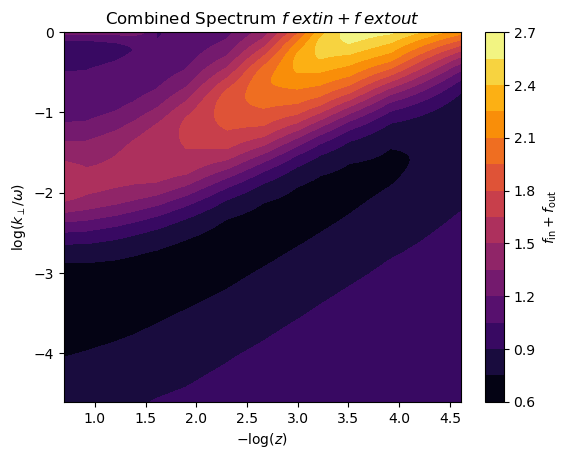

In [11]:
plt.contourf(-np.log(ZS), np.log(k_comm), 1 + Fmed.T, levels=16, cmap='inferno')
plt.xlabel(r"$-\log(z)$")
plt.ylabel(r"$\log(k_\perp / \omega)$")
plt.title("Combined Spectrum $f_\text{in} + f_\text{out}$")
plt.colorbar(label=r"$f_\text{in} + f_\text{out}$")
plt.show()